In [1]:
!which python

/home/mnbvcxz123/Documents/Low-Latency-Trading-Engine/venv/bin/python


In [2]:
import polars as pl

FILE_PATH = 'binance_top5_data.csv'

In [3]:
column_names = ['timestamp']
for i in range(1, 6):
    column_names.extend([f"bid_p{i}", f"bid_v{i}"])
for i in range(1, 6):
    column_names.extend([f"ask_p{i}", f"ask_v{i}"])
    
df = pl.scan_csv(
    FILE_PATH,
    has_header=False,
    new_columns=column_names,
    truncate_ragged_lines=True).head(700000)

In [4]:
df.head(5).collect()

timestamp,bid_p1,bid_v1,bid_p2,bid_v2,bid_p3,bid_v3,bid_p4,bid_v4,bid_p5,bid_v5,ask_p1,ask_v1,ask_p2,ask_v2,ask_p3,ask_v3,ask_p4,ask_v4,ask_p5,ask_v5
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2026-02-28 22:30:44.757672""",66491.28,0.04639,66491.27,0.00016,66491.14,0.00008,66491.05,0.00008,66490.79,0.00008,66491.29,1.71045,66491.3,0.00016,66491.8,0.00008,66491.81,0.05311,66491.82,0.07204
"""2026-02-28 22:30:44.852564""",66491.28,0.04497,66491.27,0.00024,66491.14,0.00008,66491.05,0.00008,66490.79,0.00008,66491.29,1.71045,66491.3,0.00016,66491.81,0.05303,66491.82,0.07204,66492.01,0.00008
"""2026-02-28 22:30:44.954971""",66491.28,0.04505,66491.27,0.00024,66491.14,0.00008,66491.05,0.00008,66490.79,0.00008,66491.29,1.71796,66491.3,0.00016,66491.81,0.05303,66491.82,0.07204,66492.01,0.00008
"""2026-02-28 22:30:45.052903""",66491.28,0.04513,66491.27,0.00024,66491.14,0.00008,66491.05,0.00008,66490.79,0.00008,66491.29,1.71796,66491.3,0.00016,66491.81,0.05303,66491.82,0.07204,66492.01,0.00008
"""2026-02-28 22:30:45.158897""",66491.28,0.04529,66491.27,0.00024,66491.14,0.00008,66491.05,0.00008,66490.79,0.00008,66491.29,1.71796,66491.3,0.00016,66491.81,0.05303,66491.82,0.07204,66492.01,0.00008


In [5]:
TICK_SIZE = 0.08
FUTURE_STEPS = 10

q = (
    df
    .with_columns([
        ((pl.col('bid_p1') + pl.col('ask_p1')) / 2.0).alias('mid_price'),

        ((pl.col('bid_v1') - pl.col('ask_v1')) / (pl.col('bid_v1') + pl.col('ask_v1'))).alias('obi')
    ])
    .with_columns([
        pl.col('mid_price').shift(-FUTURE_STEPS).alias('future_mid_price')
    ])
    .with_columns([
        pl.when(pl.col('future_mid_price') > pl.col('mid_price') + TICK_SIZE).then(1)
        .when(pl.col('future_mid_price') < pl.col('mid_price') - TICK_SIZE).then(-1)
        .otherwise(0).alias('target')
    ])
    .drop_nulls()
)

final_df = q.collect()

In [6]:
final_df.select(['timestamp', 'mid_price', 'obi', 'target']).head(5)

timestamp,mid_price,obi,target
str,f64,f64,i32
"""2026-02-28 22:30:44.757672""",66491.285,-0.947189,0
"""2026-02-28 22:30:44.852564""",66491.285,-0.948764,0
"""2026-02-28 22:30:44.954971""",66491.285,-0.948894,0
"""2026-02-28 22:30:45.052903""",66491.285,-0.948806,0
"""2026-02-28 22:30:45.158897""",66491.285,-0.948629,0


In [7]:
final_df['target'].value_counts()

target,count
i32,u32
-1,100096
1,93003
0,506891


In [8]:
analysis = final_df.group_by('target').agg([
    pl.col('obi').mean().alias('mean_obi'),
    pl.col('obi').std().alias('std_obi'),
    pl.len().alias('count')
]).sort('target')
analysis

target,mean_obi,std_obi,count
i32,f64,f64,u32
-1,-0.525449,0.574835,100096
0,-0.09171,0.609805,506891
1,0.460432,0.597686,93003


In [9]:
q_top5 = (
    df
    .with_columns([
        pl.sum_horizontal([f"bid_v{i}" for i in range(1, 6)]).alias('total_bid_v'),
        pl.sum_horizontal([f"ask_v{i}" for i in range(1, 6)]).alias('total_ask_v')
    ])
    .with_columns([
        ((pl.col('bid_p1') + pl.col('ask_p1')) / 2.0).alias('mid_price'),
        ((pl.col('total_bid_v') - pl.col('total_ask_v')) 
         / (pl.col('total_bid_v') + pl.col('total_ask_v'))).alias('obi_top5')
    ])
    .with_columns([
        pl.col('mid_price').shift(-FUTURE_STEPS).alias('future_mid_price')
    ])
    .with_columns([
        pl.when(pl.col('future_mid_price') > pl.col('mid_price') + TICK_SIZE).then(1)
        .when(pl.col('future_mid_price') < pl.col('mid_price') - TICK_SIZE).then(-1)
        .otherwise(0).alias('target')
    ])
    .drop_nulls()
)

final_df_top5 = q_top5.collect()

In [10]:
analysis_top5 = final_df_top5.group_by('target').agg([
    pl.col('obi_top5').mean().alias('mean_obi_top5'),
    pl.col('obi_top5').std().alias('std_obi_top5'),
    pl.len().alias('count')
]).sort('target')
analysis_top5

target,mean_obi_top5,std_obi_top5,count
i32,f64,f64,u32
-1,-0.530185,0.576079,100096
0,-0.094479,0.613432,506891
1,0.456174,0.601375,93003


In [11]:
# %pip install xgboost scikit-learn pandas

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

In [13]:
X = final_df.select(['obi']).to_numpy()
y = final_df.select(['target']).to_numpy().ravel()

y = y + 1

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual -1', 'Actual 0', 'Actual 1'],
                     columns=['Pred -1', 'Pred 0', 'Pred 1'])
cm_df

,Pred -1,Pred 0,Pred 1
Actual -1,4174,18797,432
Actual 0,2200,88319,3396
Actual 1,362,17354,4964


In [14]:
print(classification_report(y_test, y_pred, target_names=['Down -1', 'Stay 0', 'Up 1']))

              precision    recall  f1-score   support

     Down -1       0.62      0.18      0.28     23403
      Stay 0       0.71      0.94      0.81     93915
        Up 1       0.56      0.22      0.32     22680

    accuracy                           0.70    139998
   macro avg       0.63      0.45      0.47    139998
weighted avg       0.67      0.70      0.64    139998



In [15]:
import numpy as np

In [16]:
y_probs = model.predict_proba(X_test)

CONFIDENCE_THRESH = 0.60

prob_down = y_probs[:,0]
prob_up = y_probs[:,2]

custom_preds = np.ones(len(y_probs))
custom_preds[prob_down > CONFIDENCE_THRESH] = 0
custom_preds[prob_up > CONFIDENCE_THRESH] = 2

In [17]:
print(classification_report(y_test, custom_preds, target_names=['Down -1', 'Stay 0', 'Up 1']))

              precision    recall  f1-score   support

     Down -1       0.69      0.02      0.03     23403
      Stay 0       0.68      0.98      0.81     93915
        Up 1       0.61      0.14      0.22     22680

    accuracy                           0.68    139998
   macro avg       0.66      0.38      0.35    139998
weighted avg       0.67      0.68      0.58    139998



In [18]:
#%pip install matplotlib

In [19]:
import matplotlib.pyplot as plt

In [20]:
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(23403), np.int32(1): np.int64(93915), np.int32(2): np.int64(22680)}


In [21]:
#%pip install pyarrow

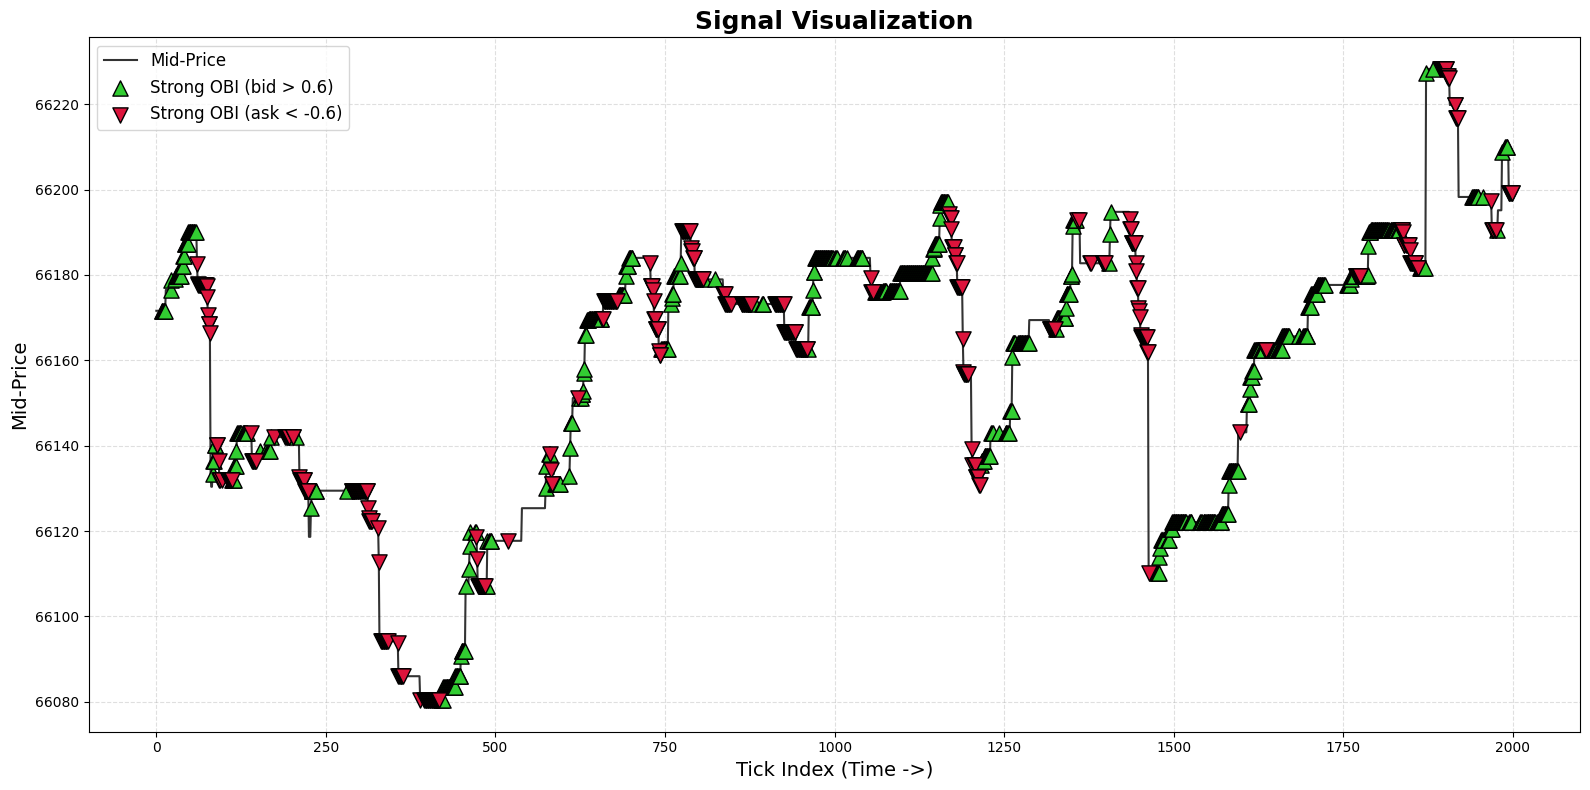

In [22]:
plot_df = final_df.tail(2000).to_pandas()

x = np.arange(len(plot_df))
y_mid = plot_df['mid_price']
obi = plot_df['obi']

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(x, y_mid, label='Mid-Price', color='black', linewidth=1.5, alpha=0.8)

bid_mask = obi > CONFIDENCE_THRESH
ask_mask = obi < -CONFIDENCE_THRESH

ax.scatter(x[bid_mask], y_mid[bid_mask], color='limegreen', marker='^',
           s=120, label='Strong OBI (bid > 0.6)', zorder=5, edgecolor='black')

ax.scatter(x[ask_mask], y_mid[ask_mask], color='crimson', marker='v',
           s=120, label='Strong OBI (ask < -0.6)', zorder=5, edgecolor='black')

ax.set_title('Signal Visualization', fontsize=18, fontweight='bold')
ax.set_xlabel('Tick Index (Time ->)', fontsize=14)
ax.set_ylabel('Mid-Price', fontsize=14)
ax.legend(loc='best', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

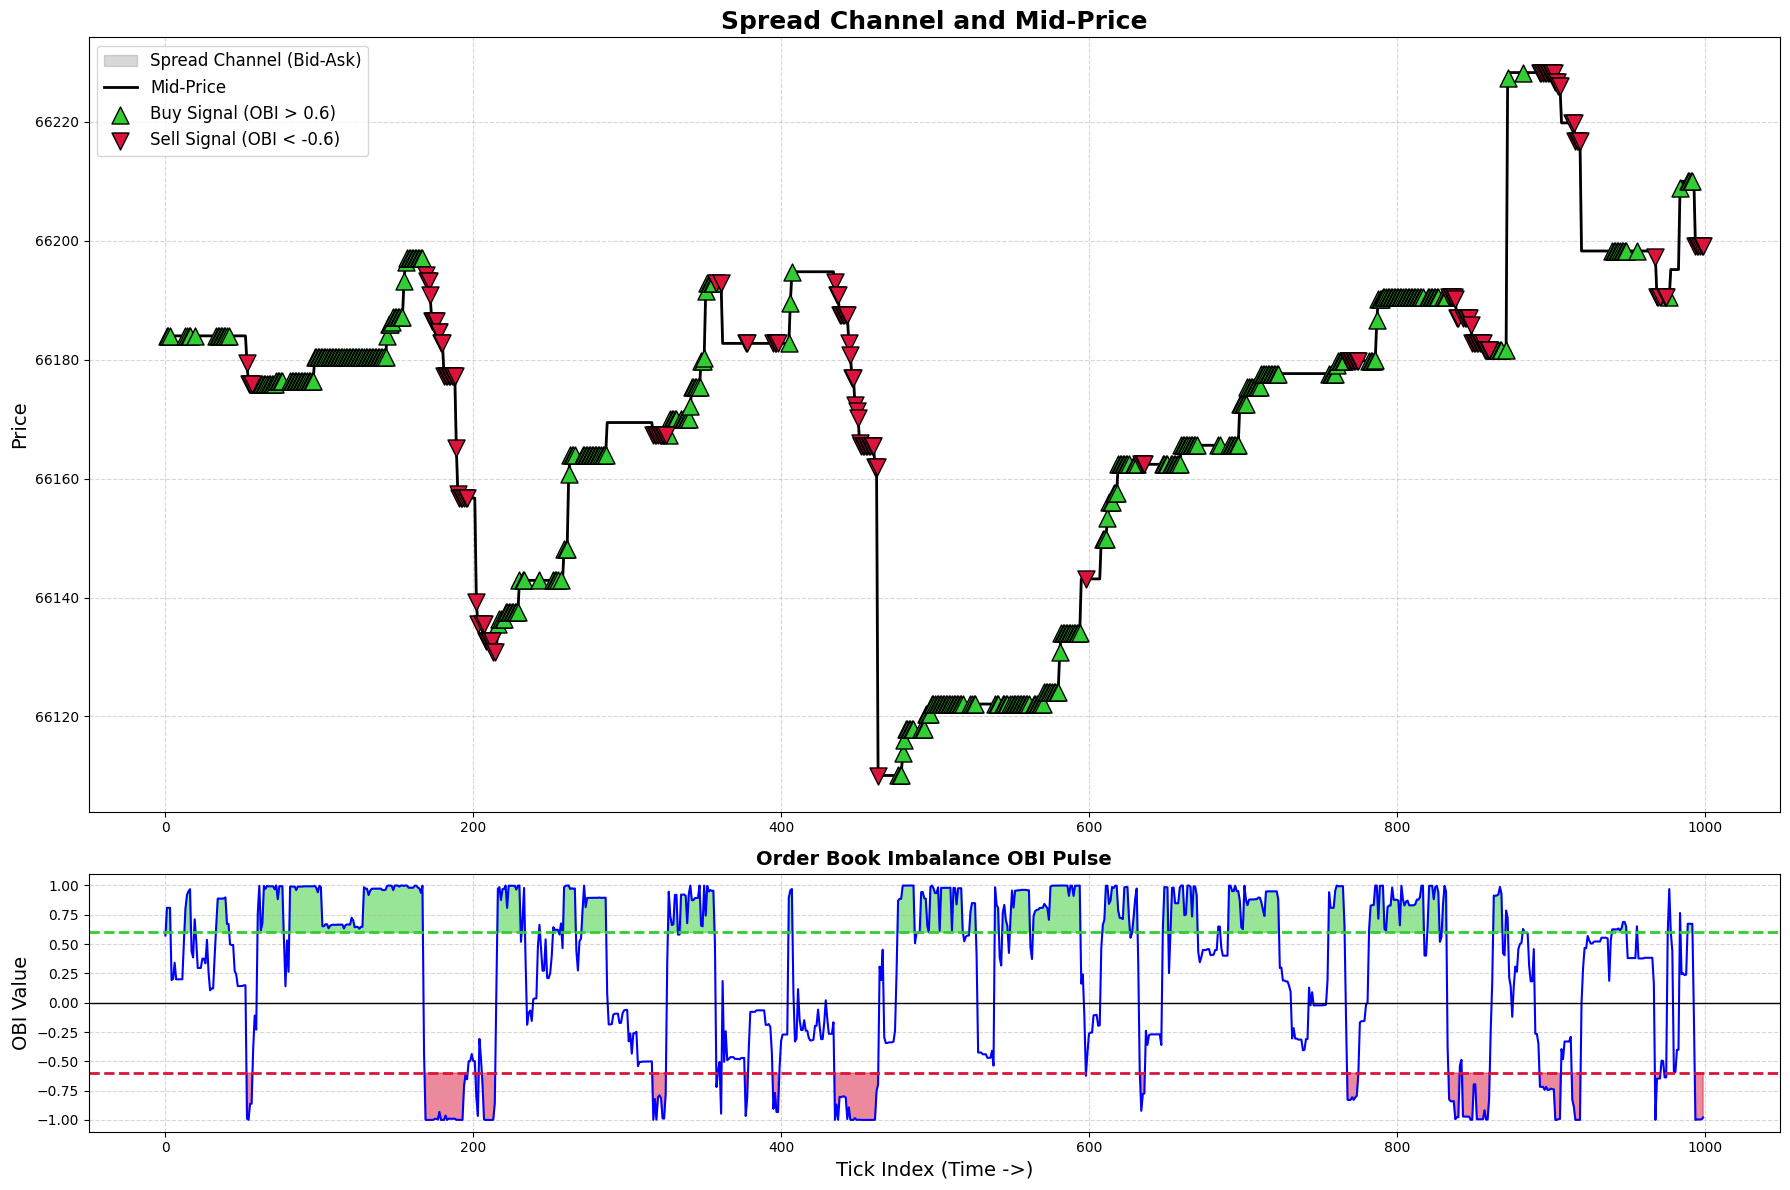

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = final_df.tail(1000).to_pandas()

x = np.arange(len(plot_df))
y_mid = plot_df['mid_price']
y_bid = plot_df['bid_p1']
y_ask = plot_df['ask_p1']
obi = plot_df['obi']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={'height_ratios': [3, 1]})

ax1.fill_between(x, y_bid, y_ask, color='gray', alpha=0.3, label='Spread Channel (Bid-Ask)')
ax1.plot(x, y_mid, label='Mid-Price', color='black', linewidth=2)

buy_mask = obi > 0.6
sell_mask = obi < -0.6
ax1.scatter(x[buy_mask], y_mid[buy_mask], color='limegreen', marker='^', s=150, zorder=5, edgecolor='black', label='Buy Signal (OBI > 0.6)')
ax1.scatter(x[sell_mask], y_mid[sell_mask], color='crimson', marker='v', s=150, zorder=5, edgecolor='black', label='Sell Signal (OBI < -0.6)')

ax1.set_title('Spread Channel and Mid-Price', fontsize=18, fontweight='bold')
ax1.set_ylabel('Price', fontsize=14)
ax1.legend(loc='best', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(x, obi, color='blue', linewidth=1.5, label='OBI L1')
ax2.axhline(0.6, color='limegreen', linestyle='--', linewidth=2)
ax2.axhline(-0.6, color='crimson', linestyle='--', linewidth=2)
ax2.axhline(0, color='black', linestyle='-', linewidth=1)

ax2.fill_between(x, obi, 0.6, where=(obi > 0.6), color='limegreen', alpha=0.5)
ax2.fill_between(x, obi, -0.6, where=(obi < -0.6), color='crimson', alpha=0.5)

ax2.set_title('Order Book Imbalance OBI Pulse', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tick Index (Time ->)', fontsize=14)
ax2.set_ylabel('OBI Value', fontsize=14)
ax2.set_ylim(-1.1, 1.1)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
q_v2 = (
    df
    .with_columns([
        pl.sum_horizontal([f"bid_v{i}" for i in range(1, 6)]).alias('total_bid_v'),
        pl.sum_horizontal([f"ask_v{i}" for i in range(1, 6)]).alias('total_ask_v')
    ])
    .with_columns([
        ((pl.col('bid_p1') + pl.col('ask_p1')) / 2.0).alias('mid_price'),
        ((pl.col('bid_v1') - pl.col('ask_v1')) / (pl.col('bid_v1') + pl.col('ask_v1'))).alias('obi'),
        
        ((pl.col('total_bid_v') - pl.col('total_ask_v')) / 
         (pl.col('total_bid_v') + pl.col('total_ask_v'))).alias('obi_top5'),
         
        (pl.col('ask_p1') - pl.col('bid_p1')).alias('spread')
    ])
    .with_columns([
        pl.col('mid_price').shift(-FUTURE_STEPS).alias('future_mid_price')
    ])
    .with_columns([
        pl.when(pl.col('future_mid_price') > pl.col('mid_price') + TICK_SIZE).then(1)
        .when(pl.col('future_mid_price') < pl.col('mid_price') - TICK_SIZE).then(-1)
        .otherwise(0).alias('target')
    ])
    .drop_nulls()
)

In [25]:
df_v2 = q_v2.collect()
df_v2.shape

(699990, 29)

In [26]:
X_v2 = df_v2.select(['obi', 'obi_top5', 'spread']).to_numpy()
y_v2 = df_v2.select(['target']).to_numpy().ravel()

y_v2 = y_v2 + 1

split = int(len(X_v2) * 0.8)
X_v2_train, X_v2_test = X_v2[:split], X_v2[split:]
y_v2_train, y_v2_test = y_v2[:split], y_v2[split:]

In [27]:
from xgboost import XGBClassifier

model_v2 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

model_v2.fit(X_v2_train, y_v2_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [28]:
y_v2_pred = model_v2.predict(X_v2_test)

cm_v2 = confusion_matrix(y_v2_test, y_v2_pred)
cm_v2_df = pd.DataFrame(cm_v2, index=['Actual -1', 'Actual 0', 'Actual 1'],
                     columns=['Pred -1', 'Pred 0', 'Pred 1'])
cm_v2_df

,Pred -1,Pred 0,Pred 1
Actual -1,4153,18739,511
Actual 0,2057,88361,3497
Actual 1,422,17089,5169


In [29]:
y_v2_probs = model_v2.predict_proba(X_v2_test)

CONFIDENCE_THRESH_v2 = 0.60

prob_v2_down = y_v2_probs[:,0]
prob_v2_up = y_v2_probs[:,2]

custom_v2_preds = np.ones(len(y_v2_probs))
custom_v2_preds[prob_v2_down > CONFIDENCE_THRESH_v2] = 0
custom_v2_preds[prob_v2_up > CONFIDENCE_THRESH_v2] = 2

In [30]:
print(classification_report(y_v2_test, custom_v2_preds, target_names=['Down -1', 'Stay 0', 'Up 1']))

              precision    recall  f1-score   support

     Down -1       0.65      0.02      0.05     23403
      Stay 0       0.69      0.98      0.81     93915
        Up 1       0.61      0.15      0.24     22680

    accuracy                           0.68    139998
   macro avg       0.65      0.38      0.37    139998
weighted avg       0.67      0.68      0.59    139998



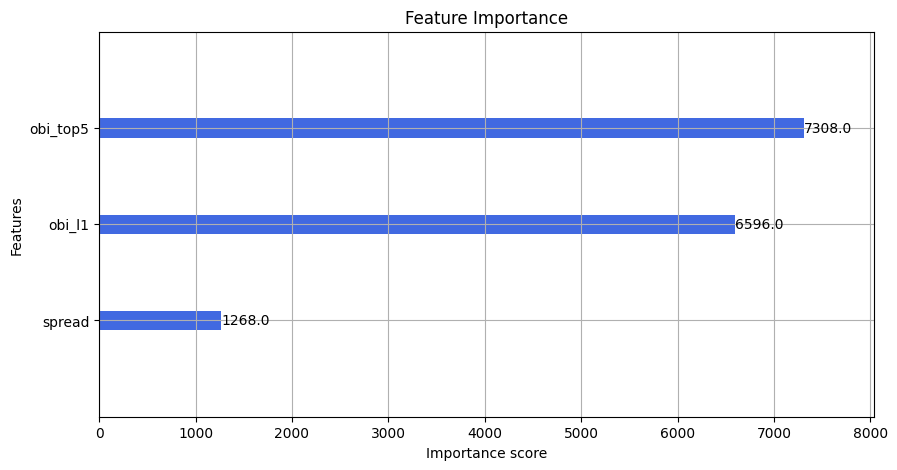

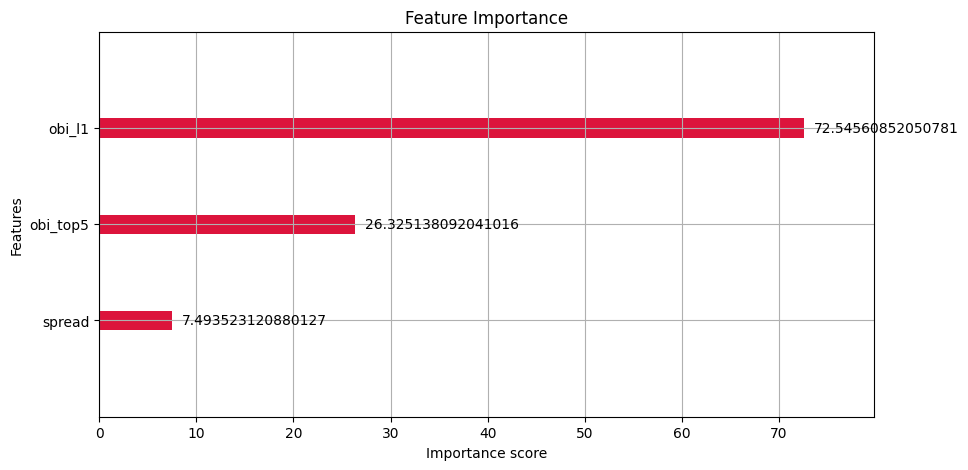

In [31]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

model_v2.get_booster().feature_names = ['obi_l1', 'obi_top5', 'spread']

fig, ax = plt.subplots(figsize=(10, 5))
plot_importance(model_v2, ax=ax, importance_type='weight', 
                title='Feature Importance',
                color='royalblue')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_importance(model_v2, ax=ax, importance_type='gain', 
                title='Feature Importance',
                color='crimson')
plt.show()

In [32]:
corr_v2_matrix = df_v2.select(['obi', 'obi_top5', 'spread']).to_pandas().corr()
corr_v2_matrix

,obi,obi_top5,spread
obi,1.000000,0.991992,0.004200
obi_top5,0.991992,1.000000,0.002939
spread,0.004200,0.002939,1.000000


In [33]:
q_v3 = (
    df
    .with_columns([
        ((pl.col('bid_p1') + pl.col('ask_p1')) / 2.0).alias('mid_price'),
        ((pl.col('bid_v1') - pl.col('ask_v1')) / (pl.col('bid_v1') + pl.col('ask_v1'))).alias('obi')
    ])
    .with_columns([
        (pl.col('mid_price') - pl.col('mid_price').shift(10)).alias('momentum_10'),
        (pl.col('mid_price') - pl.col('mid_price').shift(50)).alias('momentum_50')
    ])
    .with_columns([
        pl.col('mid_price').shift(-FUTURE_STEPS).alias('future_mid_price')
    ])
    .with_columns([
        pl.when(pl.col('future_mid_price') > pl.col('mid_price') + TICK_SIZE).then(1)
        .when(pl.col('future_mid_price') < pl.col('mid_price') - TICK_SIZE).then(-1)
        .otherwise(0).alias('target')
    ])
    .drop_nulls()
)

df_v3 = q_v3.collect()
df_v3.shape

(699940, 27)

In [34]:
X_v3 = df_v3.select(['obi', 'momentum_10', 'momentum_50']).to_numpy()
y_v3 = df_v3.select(['target']).to_numpy().ravel()

y_v3 = y_v3 + 1

split = int(len(X_v3) * 0.8)
X_v3_train, X_v3_test = X_v3[:split], X_v3[split:]
y_v3_train, y_v3_test = y_v3[:split], y_v3[split:]

In [35]:
from xgboost import XGBClassifier

model_v3 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

model_v3.fit(X_v3_train, y_v3_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [36]:
y_v3_pred = model_v3.predict(X_v3_test)

cm_v3 = confusion_matrix(y_v3_test, y_v3_pred)
cm_v3_df = pd.DataFrame(cm_v3, index=['Actual -1', 'Actual 0', 'Actual 1'],
                     columns=['Pred -1', 'Pred 0', 'Pred 1'])
cm_v3_df

,Pred -1,Pred 0,Pred 1
Actual -1,5849,16504,1040
Actual 0,2555,87676,3684
Actual 1,1089,15190,6401


In [37]:
y_v3_probs = model_v3.predict_proba(X_v3_test)

CONFIDENCE_THRESH_v3 = 0.60

prob_v3_down = y_v3_probs[:,0]
prob_v3_up = y_v3_probs[:,2]

custom_v3_preds = np.ones(len(y_v3_probs))
custom_v3_preds[prob_v3_down > CONFIDENCE_THRESH_v3] = 0
custom_v3_preds[prob_v3_up > CONFIDENCE_THRESH_v3] = 2

In [38]:
print(classification_report(y_v3_test, custom_v3_preds, target_names=['Down -1', 'Stay 0', 'Up 1']))

              precision    recall  f1-score   support

     Down -1       0.69      0.12      0.20     23393
      Stay 0       0.70      0.97      0.82     93915
        Up 1       0.64      0.17      0.26     22680

    accuracy                           0.70    139988
   macro avg       0.68      0.42      0.43    139988
weighted avg       0.69      0.70      0.62    139988



In [39]:
corr_v3_matrix = df_v3.select(['obi', 'momentum_10', 'momentum_50']).to_pandas().corr()
corr_v3_matrix

,obi,momentum_10,momentum_50
obi,1.000000,0.241919,0.240265
momentum_10,0.241919,1.000000,0.469918
momentum_50,0.240265,0.469918,1.000000


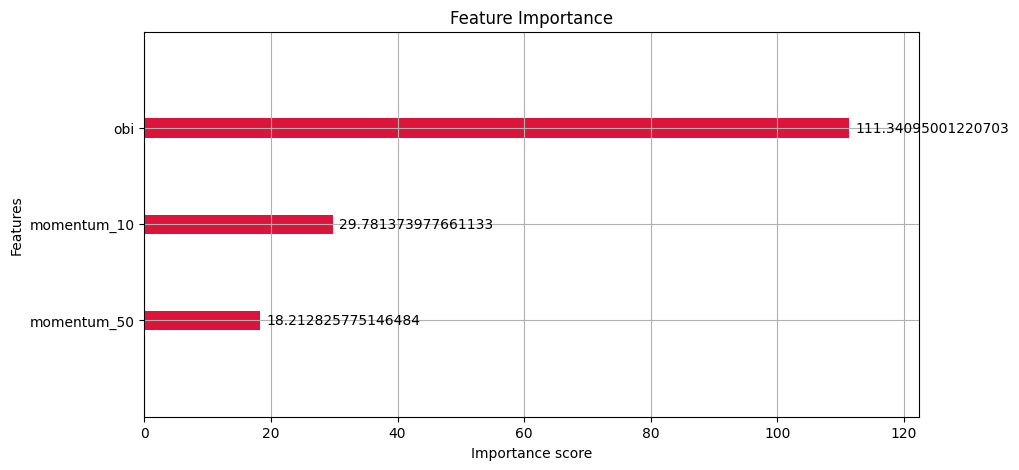

In [40]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

model_v3.get_booster().feature_names = ['obi', 'momentum_10', 'momentum_50']

fig, ax = plt.subplots(figsize=(10, 5))
plot_importance(model_v3, ax=ax, importance_type='gain', 
                title='Feature Importance',
                color='crimson')
plt.show()

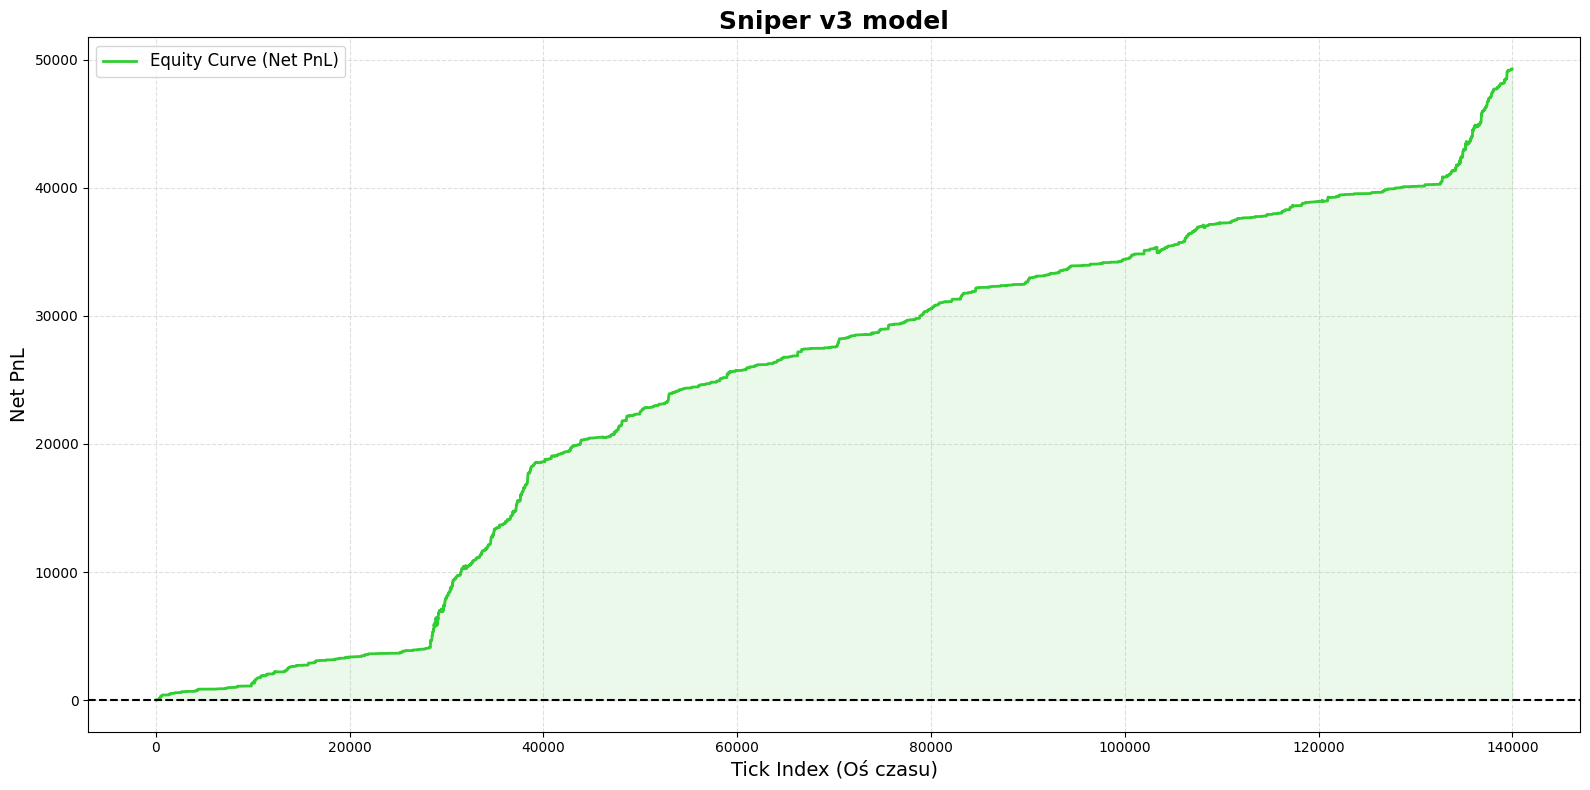

Number of Transactions: 9912
Profitable trades:     6831
Losing Trades:       3081
Win Rate: 68.92%
Net PnL: $49285.05


In [45]:
import numpy as np
import matplotlib.pyplot as plt

signals = custom_v3_preds - 1 

split_idx = int(len(df_v3) * 0.8)
test_df = df_v3[split_idx:].to_pandas()

price_diff = test_df['future_mid_price'] - test_df['mid_price']

FEE_PER_TRADE = 0.005 

gross_pnl = price_diff * signals

is_trade = (signals != 0).astype(int)
net_pnl = gross_pnl - (is_trade * FEE_PER_TRADE)

equity_curve = net_pnl.cumsum()

plt.figure(figsize=(16, 8))
plt.plot(equity_curve.values, color='limegreen', linewidth=2, label='Equity Curve (Net PnL)')
plt.title('Sniper v3 model', fontsize=18, fontweight='bold')
plt.xlabel('Tick Index (Oś czasu)', fontsize=14)
plt.ylabel('Net PnL', fontsize=14)

plt.fill_between(range(len(equity_curve)), equity_curve.values, 0, where=(equity_curve.values > 0), color='limegreen', alpha=0.1)
plt.fill_between(range(len(equity_curve)), equity_curve.values, 0, where=(equity_curve.values < 0), color='crimson', alpha=0.1)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

total_trades = is_trade.sum()
winning_trades = np.sum(net_pnl > 0)
losing_trades = np.sum(net_pnl < 0)
win_rate = winning_trades / total_trades if total_trades > 0 else 0
final_pnl = equity_curve.iloc[-1] if len(equity_curve) > 0 else 0

print(f"Number of Transactions: {total_trades}")
print(f"Profitable trades:     {winning_trades}")
print(f"Losing Trades:       {losing_trades}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Net PnL: ${final_pnl:.2f}")

In [42]:
import os

model_filename = "sniper_v3.json"

model_v3.save_model(model_filename)

file_size_mb = os.path.getsize(model_filename) / (1024 * 1024)

print(f"File: {model_filename}")
print(f"Size on the disk: {file_size_mb:.2f} MB")

File: sniper_v3.json
Size on the disk: 2.11 MB


In [46]:
FEE_RATE = 0.0002
ROUNDTRIP_FEE = FEE_RATE * 2
MIN_PROFIT_THRESH = 0.0005

FUTURE_STEPS = 10 

q_v4 = (
    df
    .with_columns([
        ((pl.col('bid_p1') + pl.col('ask_p1')) / 2.0).alias('mid_price'),
        ((pl.col('bid_v1') - pl.col('ask_v1')) / (pl.col('bid_v1') + pl.col('ask_v1'))).alias('obi')
    ])
    .with_columns([
        (pl.col('mid_price') - pl.col('mid_price').shift(10)).alias('momentum_10'),
        (pl.col('mid_price') - pl.col('mid_price').shift(50)).alias('momentum_50')
    ])
    .with_columns([
        pl.col('bid_p1').shift(-FUTURE_STEPS).alias('future_exit_bid'),
        pl.col('ask_p1').shift(-FUTURE_STEPS).alias('future_exit_ask')
    ])
    .with_columns([
        ((pl.col('future_exit_bid') - pl.col('ask_p1')) / pl.col('ask_p1')).alias('gross_long_pnl'),
        ((pl.col('bid_p1') - pl.col('future_exit_ask')) / pl.col('bid_p1')).alias('gross_short_pnl')
    ])
    .with_columns([
        pl.when(pl.col('gross_long_pnl') > (ROUNDTRIP_FEE + MIN_PROFIT_THRESH)).then(1)
        .when(pl.col('gross_short_pnl') > (ROUNDTRIP_FEE + MIN_PROFIT_THRESH)).then(-1)
        .otherwise(0).alias('target')
    ])
    .drop_nulls()
    .drop(['future_exit_bid', 'future_exit_ask', 'gross_long_pnl', 'gross_short_pnl'])
)

df_v4 = q_v4.collect()

print("Shape:", df_v4.shape)
df_v4['target'].value_counts()

Shape: (699940, 26)


target,count
i32,u32
-1,316
0,699248
1,376


In [50]:
X_v4 = df_v4.select(['obi', 'momentum_10', 'momentum_50']).to_numpy()
y_v4 = df_v4.select(['target']).to_numpy().ravel()

y_v4 = y_v4 + 1

split = int(len(X_v4) * 0.8)
X_v4_train, X_v4_test = X_v4[:split], X_v4[split:]
y_v4_train, y_v4_test = y_v4[:split], y_v4[split:]

In [51]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_v4_train 
)

model_v4 = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    reg_alpha=0.5,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric="mlogloss"
)

model_v4.fit(
    X_v4_train, 
    y_v4_train, 
    sample_weight=sample_weights,
    eval_set=[(X_v4_test, y_v4_test)],
    verbose=50
)

[0]	validation_0-mlogloss:1.07638
[50]	validation_0-mlogloss:0.53292
[100]	validation_0-mlogloss:0.34768
[150]	validation_0-mlogloss:0.25507
[200]	validation_0-mlogloss:0.19556
[250]	validation_0-mlogloss:0.15834
[300]	validation_0-mlogloss:0.13448
[350]	validation_0-mlogloss:0.11752
[400]	validation_0-mlogloss:0.10572
[450]	validation_0-mlogloss:0.09734
[499]	validation_0-mlogloss:0.09075


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

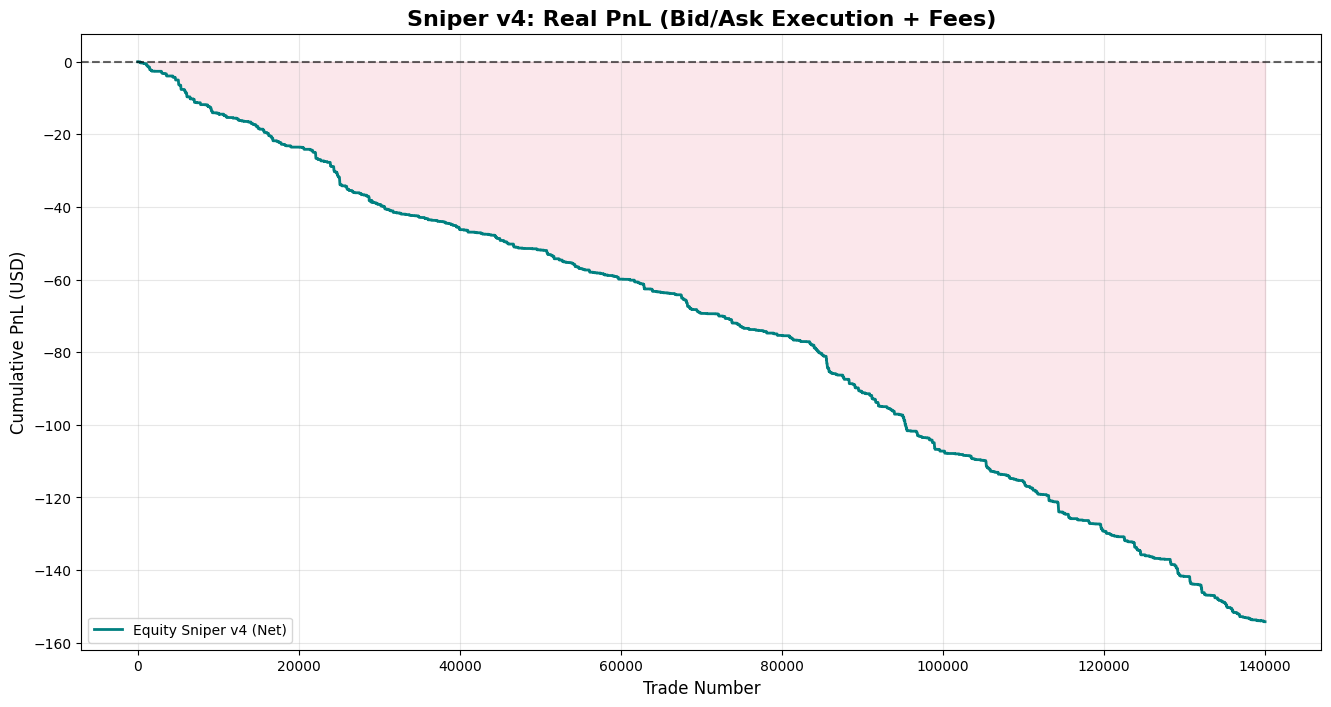

Total Transactions: 3915
Win Rate: 1.46%
Final Balance: $-154.21


In [53]:
import numpy as np
import matplotlib.pyplot as plt

probs = model_v4.predict_proba(X_v4_test)
CONFIDENCE_THRESH = 0.60

signals = np.zeros(len(probs))
signals[probs[:, 0] > CONFIDENCE_THRESH] = -1
signals[probs[:, 2] > CONFIDENCE_THRESH] = 1

split_idx = int(len(df_v4) * 0.8)
test_df = df_v4[split_idx:]

future_exit_bid = test_df['bid_p1'].shift(-FUTURE_STEPS)
future_exit_ask = test_df['ask_p1'].shift(-FUTURE_STEPS)

gross_long_pnl = (future_exit_bid - test_df['ask_p1']) / test_df['ask_p1']
gross_short_pnl = (test_df['bid_p1'] - future_exit_ask) / test_df['bid_p1']

gl_pnl = gross_long_pnl.to_numpy()
gs_pnl = gross_short_pnl.to_numpy()

roundtrip_fee = 0.0004
trade_size = 100.0 

net_pnl_usd = np.zeros(len(signals))

net_pnl_usd[signals == 1] = (gl_pnl[signals == 1] - roundtrip_fee) * trade_size
net_pnl_usd[signals == -1] = (gs_pnl[signals == -1] - roundtrip_fee) * trade_size

equity_curve = np.nancumsum(net_pnl_usd)

plt.figure(figsize=(16, 8))
plt.plot(equity_curve, color='teal', linewidth=2, label='Equity Sniper v4 (Net)')
plt.fill_between(range(len(equity_curve)), equity_curve, 0, where=(equity_curve > 0), color='teal', alpha=0.1)
plt.fill_between(range(len(equity_curve)), equity_curve, 0, where=(equity_curve < 0), color='crimson', alpha=0.1)

plt.title('Sniper v4: Real PnL (Bid/Ask Execution + Fees)', fontsize=16, fontweight='bold')
plt.xlabel('Trade Number', fontsize=12)
plt.ylabel('Cumulative PnL (USD)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

total_trades = np.sum(signals != 0)
wins = np.sum(net_pnl_usd > 0)
print(f"Total Transactions: {total_trades}")
print(f"Win Rate: {wins/total_trades:.2%}" if total_trades > 0 else "No trades")
print(f"Final Balance: ${equity_curve[-1]:.2f}" if len(equity_curve) > 0 else "N/A")

In [ ]:
%pip install seaborn
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model_v4.predict(X_v4_test)

cm = confusion_matrix(y_v4_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Short', 'Pred Stay', 'Pred Long'],
            yticklabels=['Actual Short', 'Actual Stay', 'Actual Long'])
plt.ylabel('true')
plt.xlabel('predicted')
plt.show()


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
